# Test de procesamiento de una banda
1. Cargar archivo de banda x
2. Identificar coordenada en la imagen?
3. Definir ventana espacial de 3x3
4. Correccion atmosferica ACOLITE
5. Mediana
6. Calcular indices

In [8]:
#I = B05 + B06 -> 

In [66]:
from pathlib import Path
import os
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd
import sys
import numpy as np
sys.path.append("../../external/acolite")
import acolite as ac 
import boto3
import pystac

In [28]:
BANDS_FOLDER = Path("../../data/bands/B07-B06-B05-B04-B03-B02")
matchups = gpd.read_file("../../data/registros_limpios_matchups.json")

In [29]:
#data/bands/B07-B06-B05-B04-B03-B02

In [30]:
muestra = 1
ds = xr.open_dataset(BANDS_FOLDER / f"{muestra}.nc")

In [31]:
ds

<xarray.Dataset> Size: 134kB
Dimensions:      (time: 1, y: 58, x: 48)
Coordinates:
  * time         (time) datetime64[ns] 8B 2016-12-29T13:32:22.026000
  * y            (y) float64 464B 6.149e+06 6.149e+06 ... 6.147e+06 6.147e+06
  * x            (x) float64 384B 6.779e+05 6.779e+05 ... 6.788e+05 6.788e+05
    spatial_ref  int32 4B ...
Data variables:
    B07          (time, y, x) float64 22kB ...
    B06          (time, y, x) float64 22kB ...
    B05          (time, y, x) float64 22kB ...
    B04          (time, y, x) float64 22kB ...
    B03          (time, y, x) float64 22kB ...
    B02          (time, y, x) float64 22kB ...

In [32]:
# R G B
#B04 = Red
#B03 = Green
#B02 = Blue

In [33]:
rgb = ds[["B04", "B03", "B02"]].isel(time=0).to_dataarray()
rgb

<xarray.DataArray (variable: 3, y: 58, x: 48)> Size: 67kB
array([[[0.0732, 0.0715, 0.0723, ..., 0.072 , 0.0717, 0.0699],
        [0.0721, 0.0724, 0.0711, ..., 0.0706, 0.0709, 0.0724],
        [0.0725, 0.0723, 0.0714, ..., 0.0715, 0.0699, 0.0708],
        ...,
        [0.0722, 0.0716, 0.0715, ..., 0.0719, 0.0703, 0.0711],
        [0.0717, 0.0705, 0.0714, ..., 0.0708, 0.0714, 0.0715],
        [0.0715, 0.0711, 0.072 , ..., 0.0707, 0.0708, 0.0709]],

       [[0.0829, 0.0833, 0.0829, ..., 0.0808, 0.0827, 0.0818],
        [0.0833, 0.0829, 0.082 , ..., 0.0816, 0.0813, 0.081 ],
        [0.0824, 0.0828, 0.0834, ..., 0.0817, 0.0816, 0.0803],
        ...,
        [0.0824, 0.0824, 0.0827, ..., 0.0816, 0.0819, 0.0806],
        [0.0827, 0.0829, 0.0828, ..., 0.0818, 0.0819, 0.0812],
        [0.0825, 0.0827, 0.0819, ..., 0.0813, 0.0815, 0.0818]],

       [[0.1013, 0.1011, 0.1019, ..., 0.1   , 0.1002, 0.1   ],
        [0.1017, 0.1012, 0.1018, ..., 0.1005, 0.1006, 0.0992],
        [0.102 , 0.1013, 0.1013, ..., 0.1004, 0.1   , 0.0989],
        ...,
        [0.1002, 0.1009, 0.1013, ..., 0.1009, 0.1005, 0.1   ],
        [0.1013, 0.1006, 0.1018, ..., 0.1   , 0.1006, 0.0995],
        [0.1009, 0.1004, 0.1012, ..., 0.101 , 0.1005, 0.1001]]],
      shape=(3, 58, 48))
Coordinates:
  * variable     (variable) object 24B 'B04' 'B03' 'B02'
  * y            (y) float64 464B 6.149e+06 6.149e+06 ... 6.147e+06 6.147e+06
  * x            (x) float64 384B 6.779e+05 6.779e+05 ... 6.788e+05 6.788e+05
    time         datetime64[ns] 8B 2016-12-29T13:32:22.026000
    spatial_ref  int32 4B ...

In [34]:
m = matchups.loc[muestra]
m

fecha                                           2017-01-02 00:00:00
fuente                                                         GEMS
chla                                                            6.8
grupo_nombre                                                    LDS
estado_trofico                                                    O
delta                                        3 days 10:27:37.974000
pass_id           S2A_MSIL1C_20161229T133222_N0500_R081_T21HXB_2...
geometry               POINT (678380.0015213885 6147956.9630095735)
Name: 1, dtype: object

In [35]:
px, py = m.geometry.x, m.geometry.y

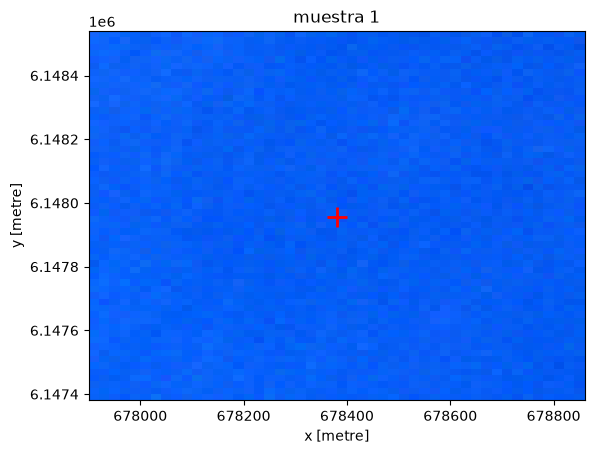

In [36]:
ax = rgb.plot.imshow(robust = True)
ax.axes.plot(px, py, "r+", markersize=15, markeredgewidth=2)
plt.title(f"muestra {muestra}")
plt.show()

In [37]:
# agarrar 3*3 alrededor del punto mostrar:
#ds["B02", "B04"]

In [38]:
A = ds[["B07", "B06", "B05", "B04", "B03", "B02"]].isel(time=0).to_dataarray()
A.shape

(6, 58, 48)

In [39]:
px, py

(678380.0015213885, 6147956.9630095735)

In [40]:
#import numpy as np

#from s2cloudless import S2PixelCloudDetector
A.shape # (N, 

(6, 58, 48)

In [72]:
center_y = A.shape[1] // 2
center_x = A.shape[2] // 2
WINDOW_SIZE = 3
half_w = WINDOW_SIZE // 2
window = A[:, center_y-half_w:center_y+half_w+1, center_x-half_w:center_x+half_w+1] #
window

<xarray.DataArray (variable: 6, y: 3, x: 3)> Size: 432B
array([[[0.0413, 0.0411, 0.0418],
        [0.0413, 0.0413, 0.0413],
        [0.0413, 0.0409, 0.0406]],

       [[0.0416, 0.041 , 0.0409],
        [0.0415, 0.0415, 0.0411],
        [0.041 , 0.0419, 0.0409]],

       [[0.065 , 0.0653, 0.0652],
        [0.0657, 0.0656, 0.065 ],
        [0.0644, 0.0648, 0.065 ]],

       [[0.0709, 0.0722, 0.0716],
        [0.0718, 0.072 , 0.0709],
        [0.0704, 0.0714, 0.0708]],

       [[0.0823, 0.0819, 0.0813],
        [0.0815, 0.0803, 0.082 ],
        [0.0818, 0.0819, 0.0812]],

       [[0.1009, 0.1001, 0.1009],
        [0.1004, 0.1004, 0.1   ],
        [0.101 , 0.1006, 0.1015]]])
Coordinates:
  * variable     (variable) object 48B 'B07' 'B06' 'B05' 'B04' 'B03' 'B02'
  * y            (y) float64 24B 6.148e+06 6.148e+06 6.148e+06
  * x            (x) float64 24B 6.784e+05 6.784e+05 6.784e+05
    time         datetime64[ns] 8B 2016-12-29T13:32:22.026000
    spatial_ref  int32 4B 32721

In [73]:
window.shape

(6, 3, 3)

In [74]:
np.mean(window, axis=1) 

<xarray.DataArray (variable: 6, x: 3)> Size: 144B
array([[0.0413    , 0.0411    , 0.04123333],
       [0.04136667, 0.04146667, 0.04096667],
       [0.06503333, 0.06523333, 0.06506667],
       [0.07103333, 0.07186667, 0.0711    ],
       [0.08186667, 0.08136667, 0.0815    ],
       [0.10076667, 0.10036667, 0.1008    ]])
Coordinates:
  * variable     (variable) object 48B 'B07' 'B06' 'B05' 'B04' 'B03' 'B02'
  * x            (x) float64 24B 6.784e+05 6.784e+05 6.784e+05
    time         datetime64[ns] 8B 2016-12-29T13:32:22.026000
    spatial_ref  int32 4B 32721

In [75]:
#import numpy as np
#from s2cloudless import S2PixelCloudDetector
#
## s2cloudless needs exactly these 10 bands, in THIS order.
## B10 (cirrus) only exists in L1C — which is why this is an L1C classifier.
#S2CLOUDLESS_BANDS = ["B01","B02","B04","B05","B08","B8A","B09","B10","B11","B12"]
#
## 1. load those bands for the pass (odc resamples them all onto one grid)
#ds = odc.stac.load([item_1], bands=S2CLOUDLESS_BANDS, resolution=RES,
#                   bbox=bbox, chunks=None, resampling="average")
#
## 2. to reflectance 0–1 (your scale/offset function, or /10000 with the offset)
#ds = to_reflectance(ds, item_1)
#
#SADASD
#
## 3. stack to (time, y, x, band) — the shape s2cloudless wants
#arr = np.stack([ds[b].values for b in S2CLOUDLESS_BANDS], axis=-1).astype("float32")
#
## 4. run it
#detector = S2PixelCloudDetector(threshold=0.4, average_over=0, dilation_size=0,
#                                all_bands=False)
#prob = detector.get_cloud_probability_maps(arr)   # (time, y, x) float prob 0–1
#mask = detector.get_cloud_masks(arr)              # (time, y, x) 0/1
#
## 5. cloud fraction over your window
#cloud_frac = mask[0].mean()

In [76]:
#BANDS = ["B07", "B06", "B05", "B04", "B03", "B02"]
##ds.data_vars
## paso 2 y 3 ya están hechos
#

In [77]:
#arr = np.stack([ds[b].values for b in BANDS], axis=-1).astype("float32")

In [78]:
#arr.shape # T, N, M, NUM_BANDS

In [79]:
# 4. run it
#detector = S2PixelCloudDetector(threshold=0.4, average_over=0, dilation_size=0, all_bands= T)

In [80]:
#prob = detector.get_cloud_probability_maps(arr)   # (time, y, x) float prob 0–1

In [87]:
import boto3
from dotenv import load_dotenv
load_dotenv()

BUCKET_NAME = "eodata"

s3 = boto3.client(
    "s3",
    endpoint_url="https://eodata.dataspace.copernicus.eu",
    aws_access_key_id=os.environ["CDSE_S3_ACCESS_KEY"],
    aws_secret_access_key=os.environ["CDSE_S3_SECRET_KEY"],
)

In [88]:
DATA = Path("../data")

In [89]:
ic = pystac.ItemCollection.from_file("../../data/matchup_items.json")
item_by_id = {item.id: item for item in ic}

In [94]:
def download_safe(item, dest=DATA / "safe"):
    key = item.assets["product_metadata"].href.replace("s3://eodata/", "")
    prefix = key.rsplit("/", 1)[0]
    local = dest / prefix.split("/")[-1]
    paginator = s3.get_paginator("list_objects_v2")
    for page in paginator.paginate(Bucket=BUCKET_NAME, Prefix=prefix):
        for obj in page.get("Contents", []):
            rel = obj["Key"][len(prefix)+1:]
            out = local / rel
            out.parent.mkdir(parents=True, exist_ok=True)
            if not out.exists():
                s3.download_file(BUCKET_NAME, obj["Key"], str(out))
    return local

In [95]:
def run_acolite(safe_path, limit, out_dir):
    settings = {
        "inputfile": str(safe_path),
        "output": str(out_dir),
        "limit": limit,
        "s2_target_res": 20,
        "l2w_parameters": ["Rrs_*"],
        "ancillary_data": False,
        "l2w_mask": False,
    }
    ac.acolite.acolite_run(settings=settings)

In [96]:
# 1. el punto
m = matchups.to_crs("EPSG:4326").loc[muestra]
lon, lat = m.geometry.x, m.geometry.y

# 2. zona a procesar (S, W, N, E)
d = 0.005
limit = [lat - d, lon - d, lat + d, lon + d]

# 3. bajar el .SAFE de esa pasada (tarda, es 1 vez por escena)
safe = download_safe(item_by_id[m.pass_id])

# 4. correr ACOLITE
out_dir = DATA / "acolite" / m.pass_id
out_dir.mkdir(parents=True, exist_ok=True)
run_acolite(safe, limit, out_dir)

# 5. abrir la salida
nc = glob.glob(str(out_dir / "*_L2W.nc"))[0]
ds = xr.open_dataset(nc)

# 6. quedarse solo con las bandas Rrs
rrs = ds[[v for v in ds.data_vars if v.startswith("Rrs_")]]
print(list(rrs.data_vars))

Running ACOLITE processing - GitHub Clone
Python - linux - 3.11.15 (main, Aug  5 2026, 15:45:52) [Clang 22.1.3 ]
Platform - Linux 7.0.11-76070011-generic - x86_64 - #202606011647~1784215097~24.04~4974880 SMP PREEMPT_DYNAMIC Thu J
Run ID - 20260914_231714
Identified ../data/safe/S2A_MSIL1C_20161229T133222_N0500_R081_T21HXB_20230923T131421.SAFE as Sentinel-2 .SAFE type
Starting conversion of 1 scenes
Starting conversion of ../data/safe/S2A_MSIL1C_20161229T133222_N0500_R081_T21HXB_20230923T131421.SAFE
Importing metadata from L1C_T21HXB_A007943_20161229T133909
Reading per pixel geometry


ImportError: cannot import name '_gdal_array' from 'osgeo' (/home/enzotrindade/ProyectoAA/.venv/lib/python3.11/site-packages/osgeo/__init__.py)